##Q1

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
# Load the dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00194/sensor_readings_24.data"
column_names = ["Attribute_" + str(i) for i in range(1, 25)] + ["Class"]
data = pd.read_csv(url, names=column_names)


In [ ]:
data

,Attribute_1,Attribute_2,Attribute_3,Attribute_4,Attribute_5,Attribute_6,Attribute_7,Attribute_8,Attribute_9,Attribute_10,...,Attribute_16,Attribute_17,Attribute_18,Attribute_19,Attribute_20,Attribute_21,Attribute_22,Attribute_23,Attribute_24,Class
0,0.438,0.498,3.625,3.645,5.000,2.918,5.000,2.351,2.332,2.643,...,0.593,0.502,0.493,0.504,0.445,0.431,0.444,0.440,0.429,Slight-Right-Turn
1,0.438,0.498,3.625,3.648,5.000,2.918,5.000,2.637,2.332,2.649,...,0.592,0.502,0.493,0.504,0.449,0.431,0.444,0.443,0.429,Slight-Right-Turn
2,0.438,0.498,3.625,3.629,5.000,2.918,5.000,2.637,2.334,2.643,...,0.593,0.502,0.493,0.504,0.449,0.431,0.444,0.446,0.429,Slight-Right-Turn
3,0.437,0.501,3.625,3.626,5.000,2.918,5.000,2.353,2.334,2.642,...,0.593,0.502,0.493,0.504,0.449,0.431,0.444,0.444,0.429,Slight-Right-Turn
4,0.438,0.498,3.626,3.629,5.000,2.918,5.000,2.640,2.334,2.639,...,0.592,0.502,0.493,0.504,0.449,0.431,0.444,0.441,0.429,Slight-Right-Turn
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5451,0.910,5.000,3.997,2.785,2.770,2.572,2.433,1.087,1.772,1.040,...,0.660,0.648,0.657,0.686,5.000,1.045,5.000,5.000,1.562,Move-Forward
5452,0.926,5.000,4.015,2.792,2.777,2.571,1.768,1.071,1.762,1.021,...,0.652,0.640,0.649,1.593,1.616,1.058,5.000,5.000,1.085,Sharp-Right-Turn
5453,0.937,5.000,4.034,2.799,2.784,2.571,1.754,1.053,1.752,1.002,...,0.648,0.633,0.642,0.741,5.000,1.065,5.000,5.000,1.105,Sharp-Right-Turn
5454,0.945,4.052,4.052,2.809,2.791,2.441,1.757,1.034,1.743,0.983,...,0.641,0.626,0.635,0.754,5.000,1.076,5.000,5.000,1.118,Move-Forward


In [ ]:
data.shape

(5456, 25)

In [29]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5456 entries, 0 to 5455
Data columns (total 25 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Attribute_1   5456 non-null   float64
 1   Attribute_2   5456 non-null   float64
 2   Attribute_3   5456 non-null   float64
 3   Attribute_4   5456 non-null   float64
 4   Attribute_5   5456 non-null   float64
 5   Attribute_6   5456 non-null   float64
 6   Attribute_7   5456 non-null   float64
 7   Attribute_8   5456 non-null   float64
 8   Attribute_9   5456 non-null   float64
 9   Attribute_10  5456 non-null   float64
 10  Attribute_11  5456 non-null   float64
 11  Attribute_12  5456 non-null   float64
 12  Attribute_13  5456 non-null   float64
 13  Attribute_14  5456 non-null   float64
 14  Attribute_15  5456 non-null   float64
 15  Attribute_16  5456 non-null   float64
 16  Attribute_17  5456 non-null   float64
 17  Attribute_18  5456 non-null   float64
 18  Attribute_19  5456 non-null 

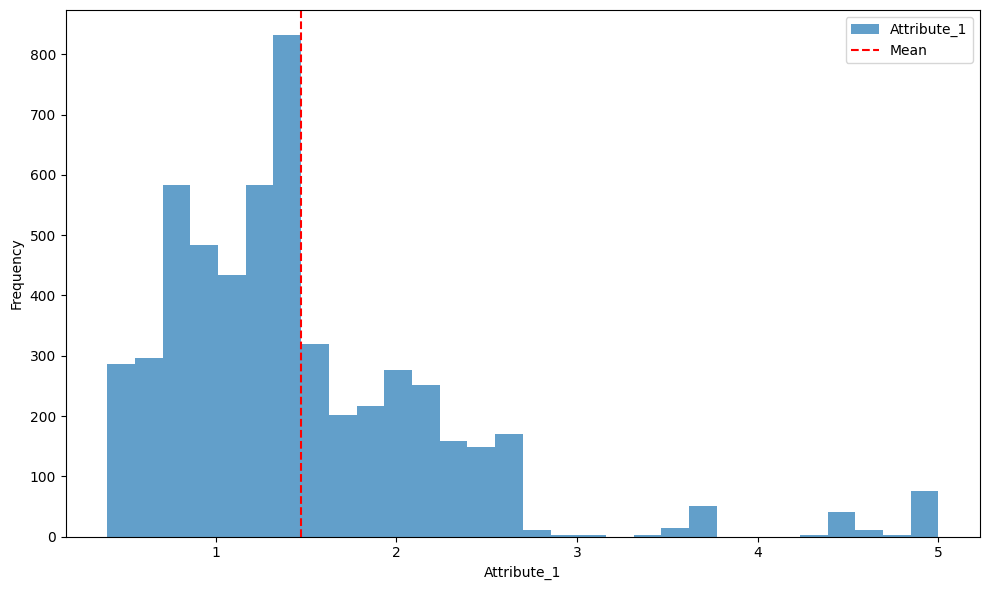

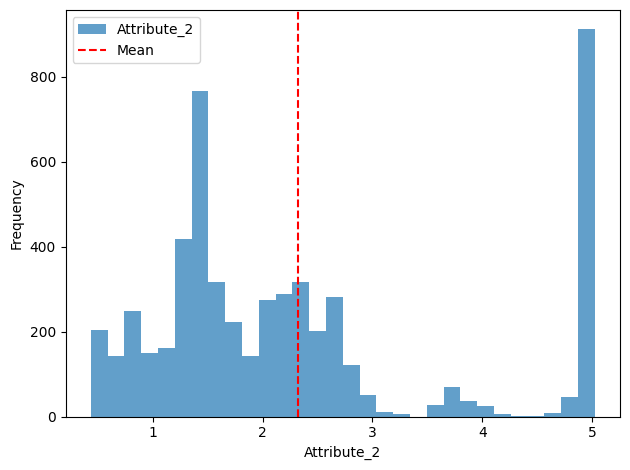

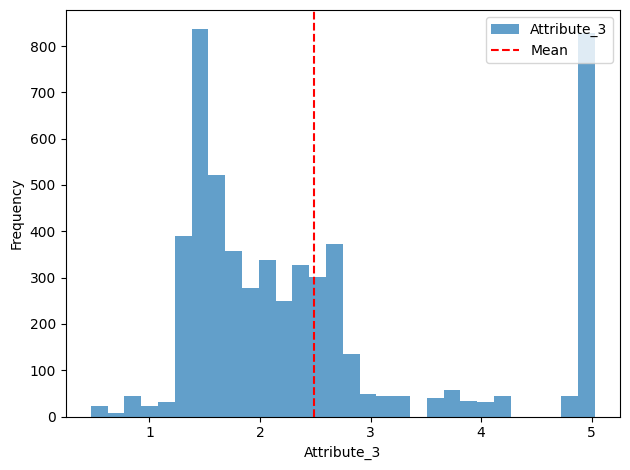

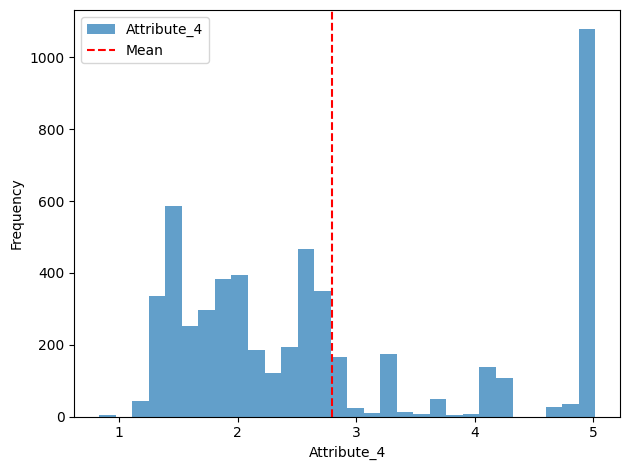

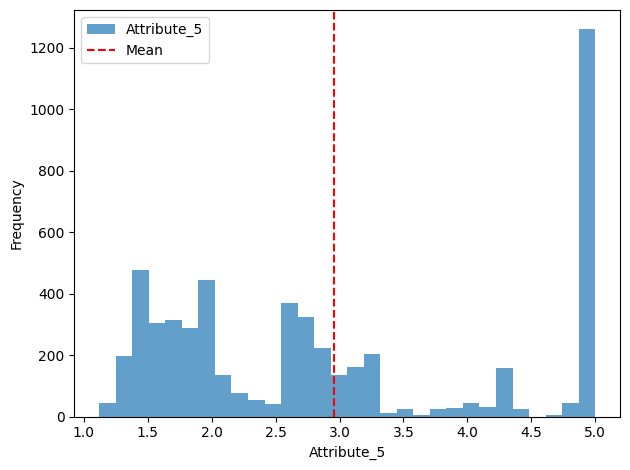

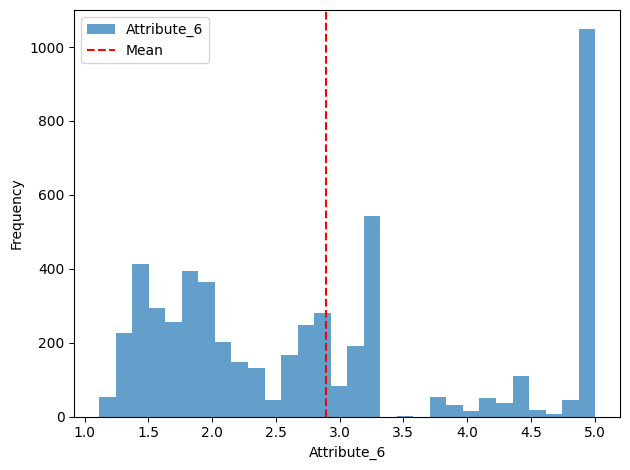

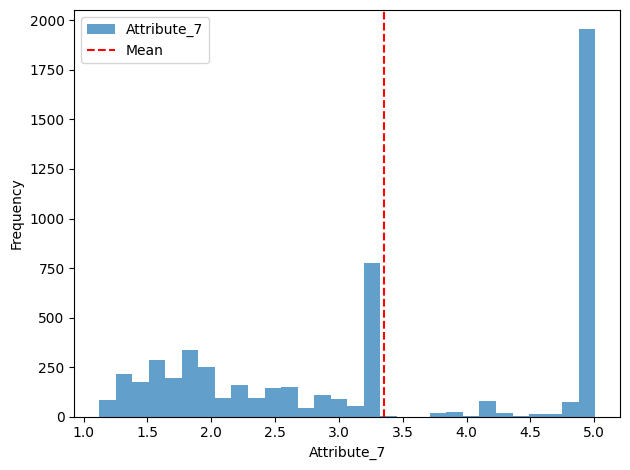

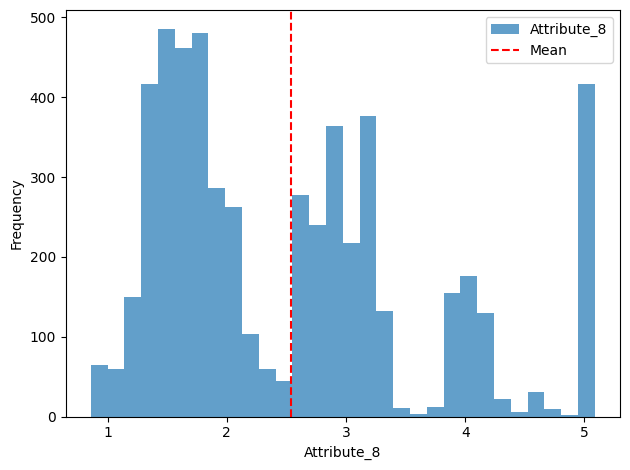

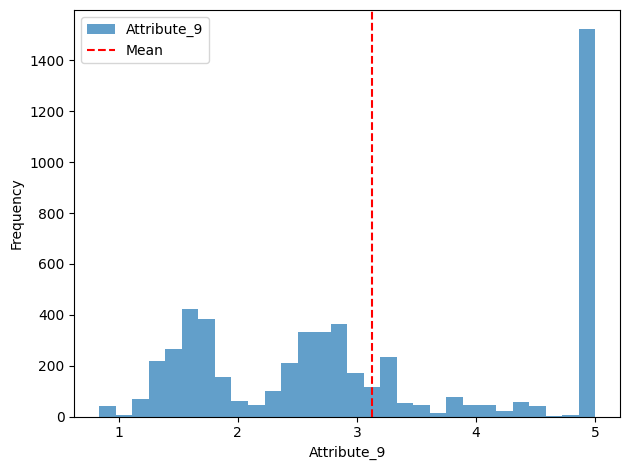

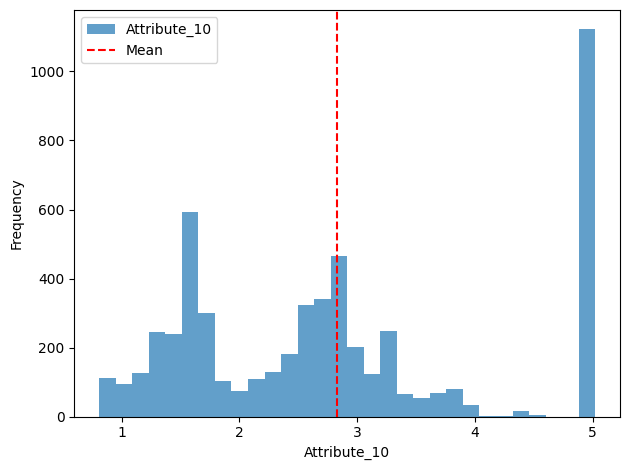

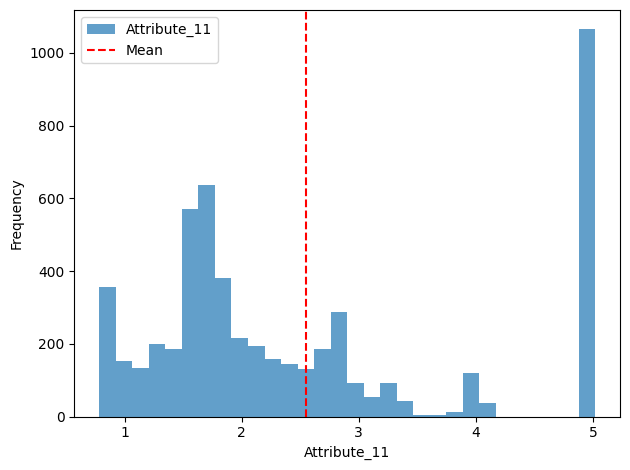

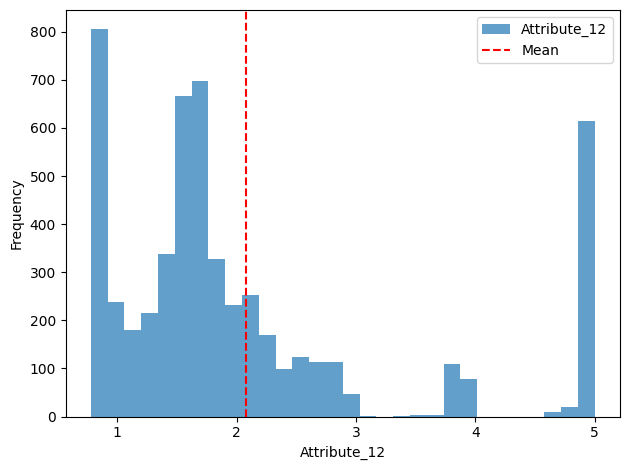

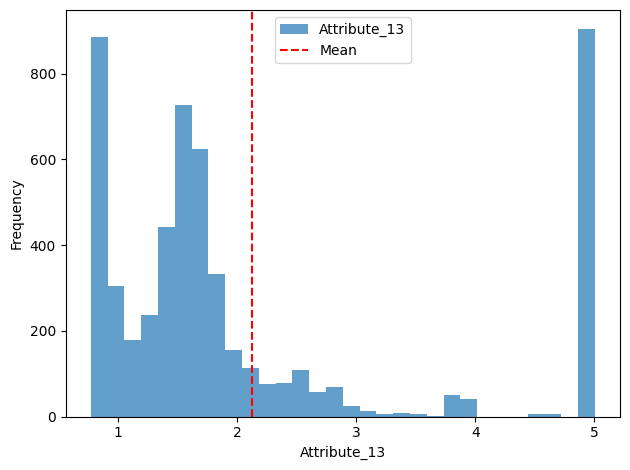

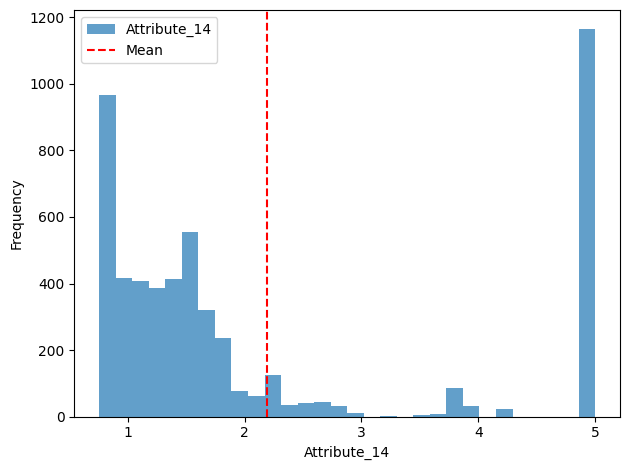

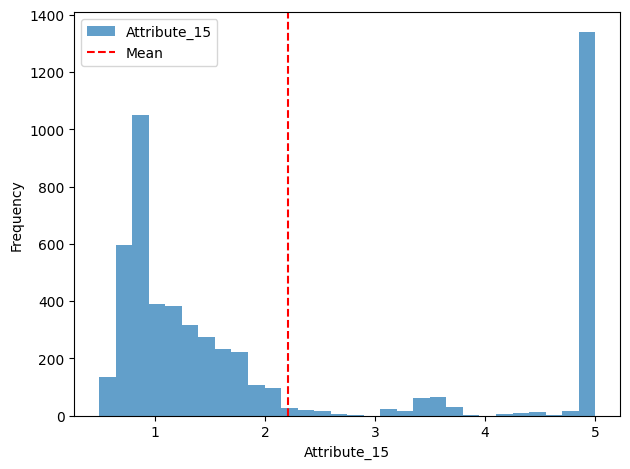

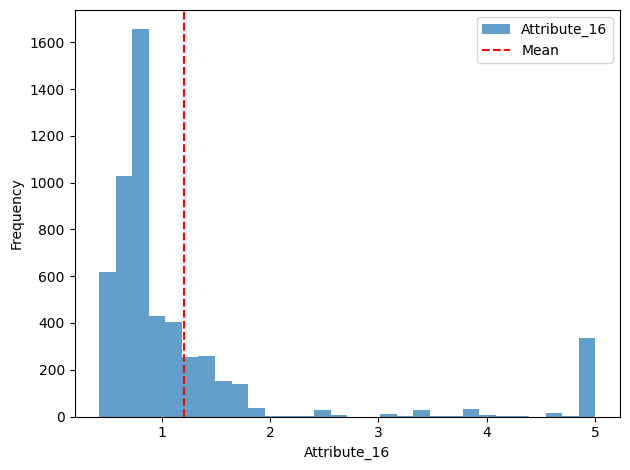

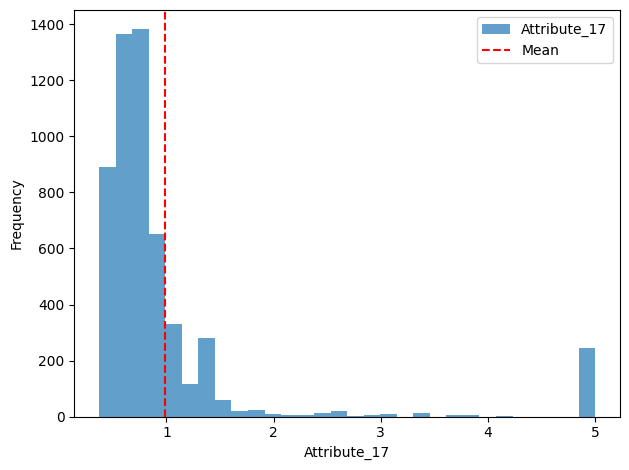

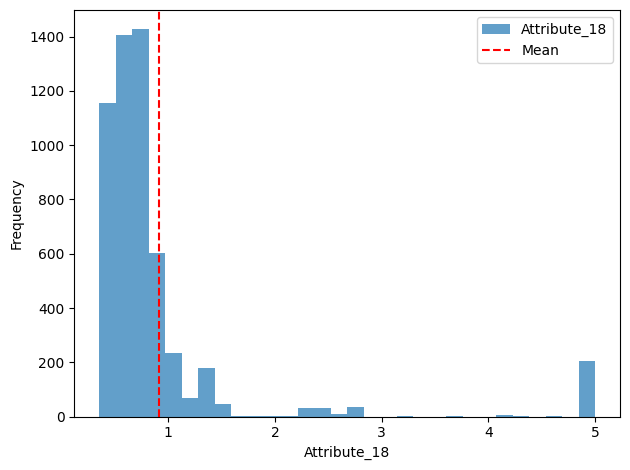

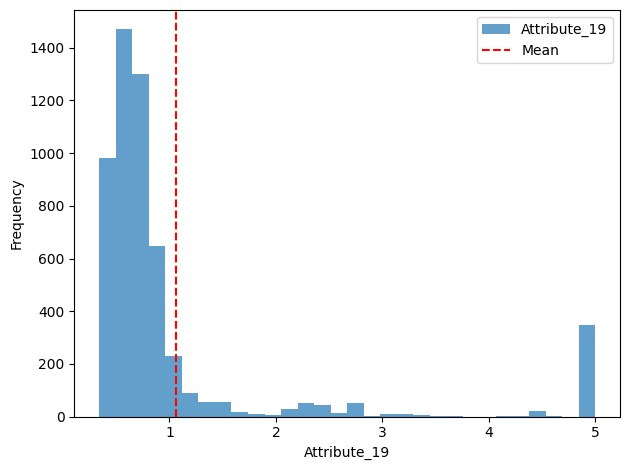

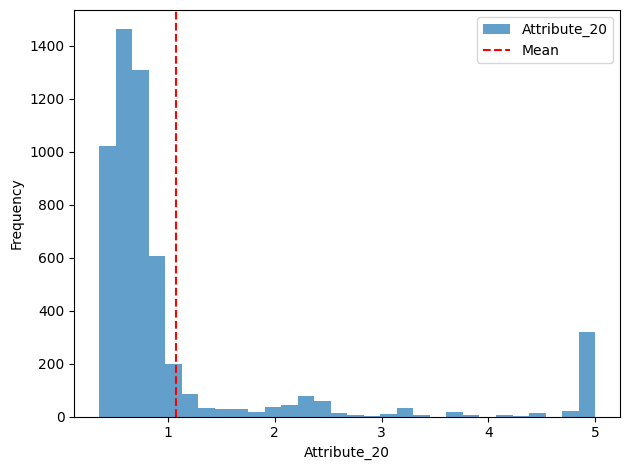

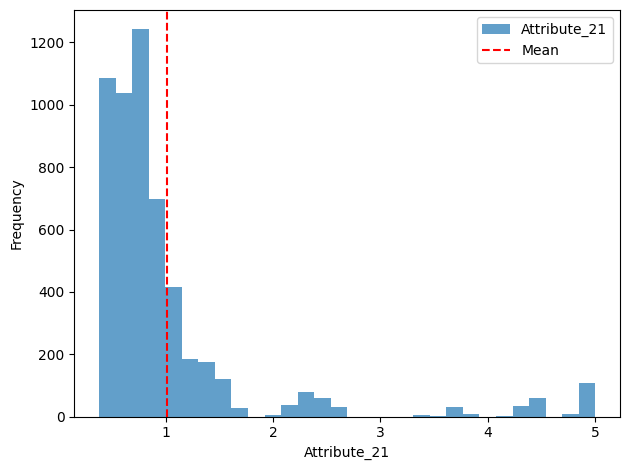

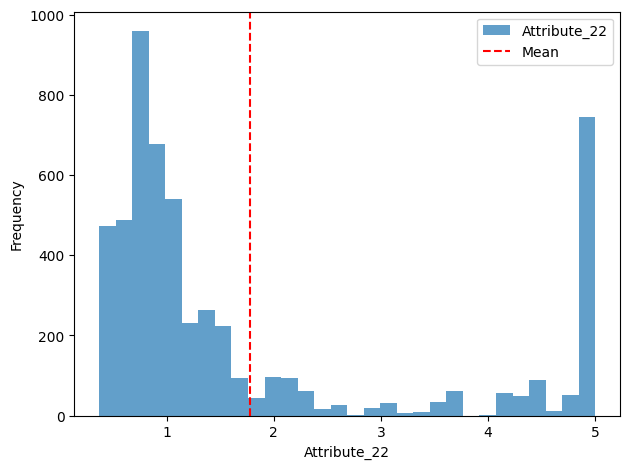

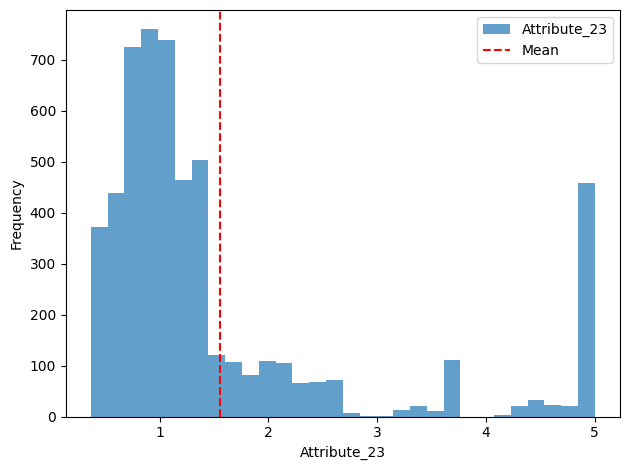

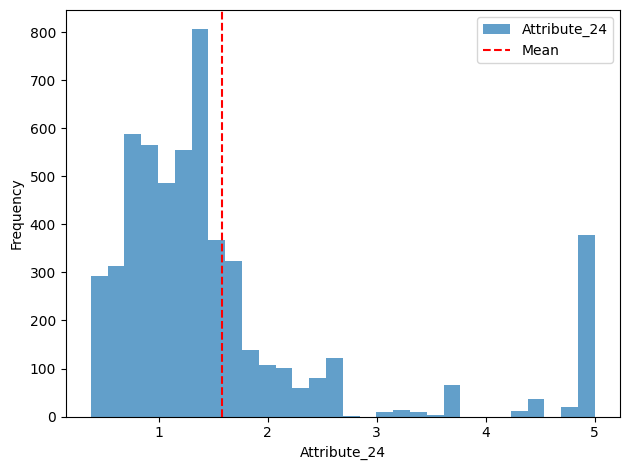

In [ ]:
# Plot histograms with mean line
plt.figure(figsize=(10, 6))
for column in data.columns:
    if column != 'Class':  # Exclude the target variable from histograms
        mean_value = data[column].mean()
        plt.hist(data[column], bins=30, alpha=0.7, label=column)
        plt.axvline(mean_value, color='red', linestyle='dashed', linewidth=1.5, label='Mean')
        plt.xlabel(column)
        plt.ylabel('Frequency')
        plt.legend()
        plt.tight_layout()  # Adjust layout for better visibility
        plt.show()


In [ ]:

# Data preprocessing
X = data.drop('Class', axis=1)
y = data['Class']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [ ]:

# Model building
models = {
    "Logistic Regression": LogisticRegression(),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "AdaBoost": AdaBoostClassifier()
}


In [ ]:

results = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred)
    conf_matrix = confusion_matrix(y_test, y_pred)
    results[name] = {"accuracy": accuracy, "report": report, "confusion_matrix": conf_matrix}


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels wit

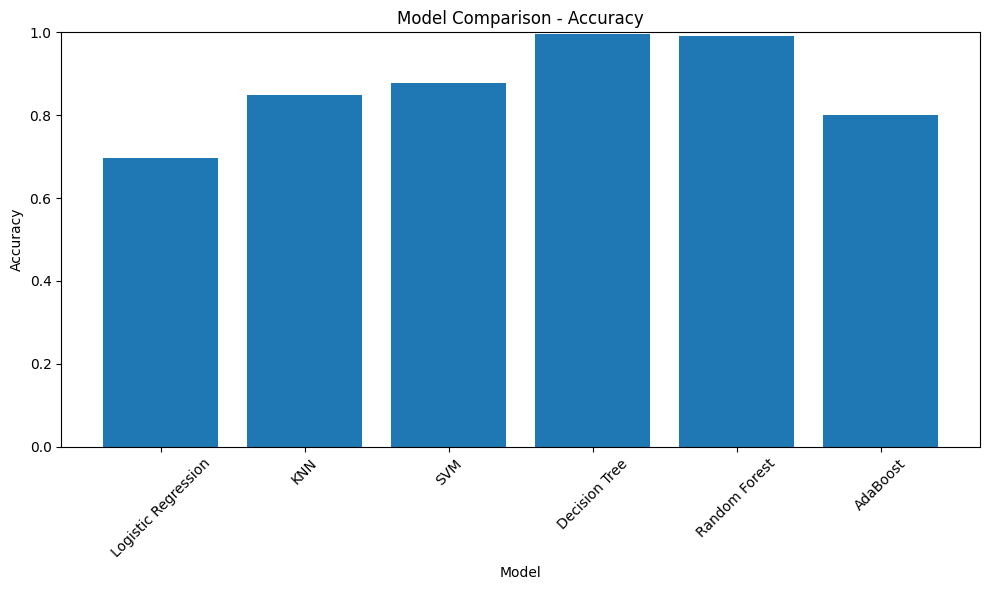

In [ ]:

# Plotting the results
accuracies = [result["accuracy"] for result in results.values()]
models_names = list(results.keys())

plt.figure(figsize=(10, 6))
plt.bar(models_names, accuracies)
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.title('Model Comparison - Accuracy')
plt.ylim([0, 1])
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [ ]:

# Print detailed results
for name, result in results.items():
    print(f"Model: {name}")
    print(f"Accuracy: {result['accuracy']:.4f}")
    print("Classification Report:\n", result['report'])
    print("Confusion Matrix:\n", result['confusion_matrix'])
    print("="*50)


Model: Logistic Regression
Accuracy: 0.6978
Classification Report:
                    precision    recall  f1-score   support

     Move-Forward       0.76      0.69      0.72       454
 Sharp-Right-Turn       0.69      0.80      0.74       427
 Slight-Left-Turn       0.57      0.47      0.51        60
Slight-Right-Turn       0.58      0.52      0.55       151

         accuracy                           0.70      1092
        macro avg       0.65      0.62      0.63      1092
     weighted avg       0.70      0.70      0.70      1092

Confusion Matrix:
 [[314  99  12  29]
 [ 51 341   6  29]
 [ 10  22  28   0]
 [ 38  31   3  79]]
Model: KNN
Accuracy: 0.8480
Classification Report:
                    precision    recall  f1-score   support

     Move-Forward       0.83      0.86      0.85       454
 Sharp-Right-Turn       0.89      0.86      0.87       427
 Slight-Left-Turn       0.91      0.85      0.88        60
Slight-Right-Turn       0.76      0.77      0.77       151

         acc

##Q2

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

## for statistical tests
import scipy
import statsmodels.formula.api as smf
import statsmodels.api as sm

## for machine learning
from sklearn import model_selection, preprocessing, feature_selection, ensemble, linear_model, metrics, decomposition

In [ ]:
df = pd.read_csv(r'C:\Users\BgTxt\Documents\tamerelapute\YearPredictionMSD.txt',header=None)
df.head()

In [ ]:
df.describe()

In [ ]:
df.head()

In [ ]:
df.isnull().sum().sum()


In [ ]:
df_train=df.iloc[:463715,:]
print(df_train.shape)
df_test=df.iloc[463715:,:]
print(df_test.shape)

In [ ]:
df_train.describe()

In [ ]:

# Print detailed results
for name, result in results.items():
    print(f"Model: {name}")
    print(f"MSE: {result['MSE']:.4f}")
    print(f"R-squared: {result['R-squared']:.4f}")
    print("="*50)


In [ ]:
# create the scaler
ss = preprocessing.StandardScaler()

# create new dataframes to keep the non scaled ones
df_train_s=df_train.copy()
df_test_s=df_test.copy()

# we delete df to free space, as we won't need it anymore
del df

# apply the scaler to the dataframe subset
df_train_s.iloc[:,1:] = ss.fit_transform(df_train_s.iloc[:,1:])
df_test_s.iloc[:,1:] = ss.transform(df_test_s.iloc[:,1:])

In [ ]:
means = pd.DataFrame(list(zip(df_train.columns, df_train.mean(), df_test.mean())),
                   columns=['variable', 'train', 'test'])
means.drop(0, inplace=True)

means = pd.melt(means, id_vars="variable", var_name="dataframe", value_name="mean")

sns.catplot(x='variable', y='mean', hue='dataframe', data=means, kind='bar', height=8, aspect=1.7)
plt.xticks(rotation = 90)
plt.title('Mean of each feature in the training and testing dataframes before scaling');

In [ ]:
means = pd.DataFrame(list(zip(df_train.columns, df_train_s.mean(), df_test_s.mean())),
                   columns=['variable', 'train scaled', 'test scaled'])
means.drop(0, inplace=True)

means = pd.melt(means, id_vars="variable", var_name="dataframe", value_name="mean")

sns.catplot(x='variable', y='mean', hue='dataframe', data=means, kind='bar', height=8, aspect=1.7)
plt.xticks(rotation = 90)
plt.title('Mean of each feature in the training and testing dataframes after scaling');

In [ ]:
maxi = pd.DataFrame(list(zip(df_train.columns, df_train.max(), df_test.max())),
                   columns=['variable', 'train', 'test'])
maxi.drop(0, inplace=True)

maxi = pd.melt(maxi, id_vars="variable", var_name="dataframe", value_name="maximum")

sns.catplot(x='variable', y='maximum', hue='dataframe', data=maxi, kind='bar', height=8, aspect=1.7)
plt.xticks(rotation = 90)
plt.title('Maximum of each feature in the training and testing dataframes before scaling');

In [ ]:
maxi = pd.DataFrame(list(zip(df_train.columns, df_train_s.max(), df_test_s.max())),
                   columns=['variable', 'train scaled', 'test scaled'])
maxi.drop(0, inplace=True)

maxi = pd.melt(maxi, id_vars="variable", var_name="dataframe", value_name="maximum")

sns.catplot(x='variable', y='maximum', hue='dataframe', data=maxi, kind='bar', height=8, aspect=1.7)
plt.xticks(rotation = 90)
plt.title('Maximum of each feature in the training and testing dataframes after scaling');

In [ ]:
sm = SMOTE()
X_train_res, y_train_res = sm.fit_sample(X_train, y_train)

In [ ]:

X_train_res = pd.DataFrame(X_train_res)
y_train_res = pd.Series(y_train_res)
X_train_res=X_train_res[0:y_train_res.size]

In [ ]:
train = pd.concat([X_train,y_train], axis=1)

In [ ]:
#Downsampling by decade
df_t = train[train.Decade>1940]
min_samples = df_t.Decade.value_counts().min()
decades = df_t.Decade.unique()
df_sampled = pd.DataFrame(columns=df_t.columns)
for decade in decades:
    df_sampled = df_sampled.append(df_t[df_t.Decade==decade].sample(min_samples))
df_sampled.Decade = df_sampled.Decade.astype(int)

In [ ]:
def models(modelName):
  name = str(modelName).split("(")[0]
  model = modelName.fit(X_train, y_train)
  ypred = np.round(model.predict(X_test),0)
  score = model.score(X_test, y_test)
  print("Model : " + name)
  print("Score: " + str(score))
  # save the model to disk
  filename = 'finalized_modelCls'+str(modelName)[0:10]+'.sav'
  pickle.dump(model, open(filename, 'wb'))

  fig, ax = plt.subplots(figsize=(12,8))
  x_ax = range(len(X_test))
  plt.scatter(x_ax, y_test, s=3, color="blue", label="original")
  plt.plot(x_ax, ypred, lw=0.8, color="red", label="predicted")
  plt.title('Predicted vs Original values for ' + name)
  plt.legend()
  plt.show()


  # plot the relative distribution of the current model
  fig, ax = plt.subplots(figsize=(12,8))
  plt.hist(ypred, color='red', alpha=0.5, label='Prediction')
  plt.hist(y_test, color='darkblue', alpha=0.5, label='True year')
  plt.legend()
  plt.title('Relative distribution with ' + name)
  plt.xlabel('Relative')
  plt.ylabel('Count')
  plt.show()

In [ ]:
models(svm.SVC(kernel='rbf',C=1,gamma=15))

In [ ]:
depths = [5,10,15,20]
n_est=[10,100,200]
for d in depths:
  for n in n_est:
    model = RandomForestClassifier(n_estimators=n,max_depth=d, random_state=0).fit(X_train,y_train)
    score = model.score(X_test, y_test)
    pred_y = model.predict(X_test)
    print("N_estimators:{0:.0f},Depth:{1:.0f}, Score:{2:.4f}"
        .format(n,d, score))

In [ ]:
models(RandomForestClassifier(n_estimators=200,max_depth=20, random_state=0))

In [ ]:
model = RandomForestClassifier(n_estimators=200,max_depth=20, random_state=0).fit(X_train, y_train)
importances = model.feature_importances_
indices = np.argsort(importances)

In [ ]:
plt.figure(figsize=(30,16))
plt.title('Feature Importances')
plt.barh(range(len(indices)), importances[indices], color='b', align='center')
plt.yticks(range(len(indices)), train.columns[indices])
plt.xlabel('Relative Importance')

In [ ]:
def modelsReg(modelName):
  name = str(modelName).split("(")[0]
  model = modelName.fit(X_train, y_train)
  ypred = np.round(model.predict(X_test),-1)
  mse = mean_squared_error(y_test, ypred)
  print("Model : " + name)
  print("MSE: " + str(mse))
  print("RMSE: " + str(math.sqrt(mse)))

  # save the model to disk
  filename = 'modReg'+str(modelName)[0:10]+'.sav'
  pickle.dump(model, open(filename, 'wb'))

  fig, ax = plt.subplots(figsize=(12,8))
  x_ax = range(len(X_test))
  plt.scatter(x_ax, y_test, s=3, color="blue", label="original")
  plt.plot(x_ax, ypred, lw=0.8, color="red", label="predicted")
  plt.title('Predicted vs Original values for ' + name)
  plt.legend()
  plt.show()


  # plot the relative distribution of the current model
  fig, ax = plt.subplots(figsize=(12,8))
  plt.hist(ypred, color='red', alpha=0.5, label='Prediction')
  plt.hist(y_test, color='darkblue', alpha=0.5, label='True year')
  plt.legend()
  plt.title('Relative distribution with ' + name)
  plt.xlabel('Relative')
  plt.ylabel('Count')
  plt.show()

In [ ]:
depths = [5,10,15,20]
n_est=[10,100,200]
for d in depths:
  for n in n_est:
    model = RandomForestRegressor(n_estimators=n,max_depth=d).fit(X_train,y_train)
    score = model.score(X_test, y_test)
    pred_y = model.predict(X_test)
    mse = mean_squared_error(y_test, pred_y)
    rmse = math.sqrt(mse)
    print("N_estimators:{0:.0f},Depth:{1:.0f}, MSE:{2:.4f}, RMSE:{3:.4f}"
        .format(n,d, mse, rmse))

##Q3

In [57]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [58]:

# Load training and testing data
training = pd.read_csv("/content/train.csv")
test  = pd.read_csv("/content/test.csv")


In [50]:

training['train_test'] = 1
test['train_test'] = 0
test['Survived'] = np.NaN
all_data = pd.concat([training,test])

%matplotlib inline
all_data.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked', 'train_test'],
      dtype='object')

In [51]:
#quick look at our data types & null counts
training.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
 12  train_test   891 non-null    int64  
dtypes: float64(2), int64(6), object(5)
memory usage: 90.6+ KB


In [52]:
# to better understand the numeric data, we want to use the .describe() method. This gives us an understanding of the central tendencies of the data
training.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,train_test
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000,891.0
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208,1.0
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429,0.0
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000,1.0
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400,1.0
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200,1.0
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000,1.0
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200,1.0


In [53]:
#quick way to separate numeric columns
training.describe().columns

Index(['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare',
       'train_test'],
      dtype='object')

In [54]:
# look at numeric and categorical values separately
df_num = training[['Age','SibSp','Parch','Fare']]
df_cat = training[['Survived','Pclass','Sex','Ticket','Cabin','Embarked']]

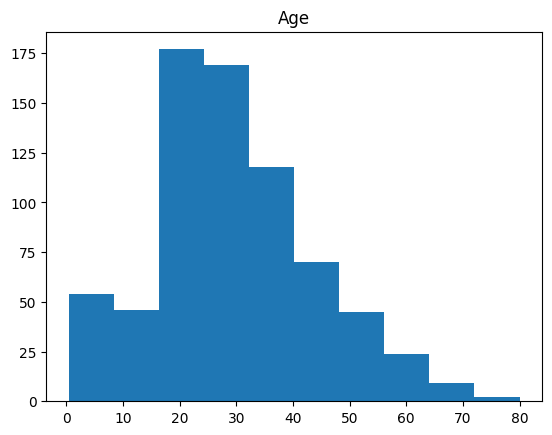

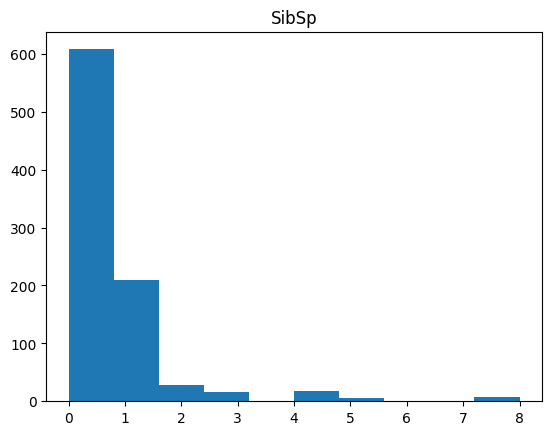

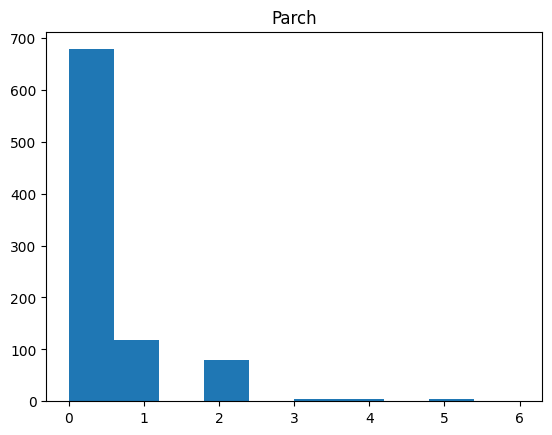

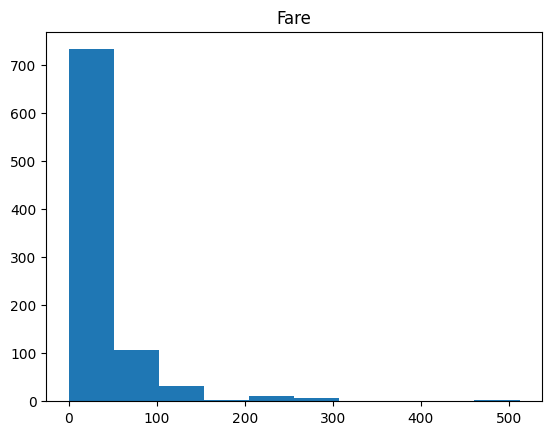

In [55]:
#distributions for all numeric variables
for i in df_num.columns:
    plt.hist(df_num[i])
    plt.title(i)
    plt.show()

            Age     SibSp     Parch      Fare
Age    1.000000 -0.308247 -0.189119  0.096067
SibSp -0.308247  1.000000  0.414838  0.159651
Parch -0.189119  0.414838  1.000000  0.216225
Fare   0.096067  0.159651  0.216225  1.000000


<Axes: >

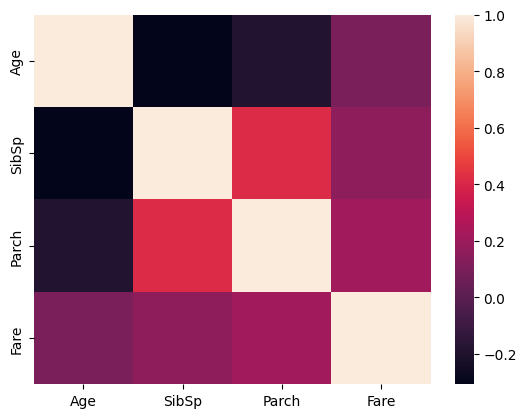

In [59]:
print(df_num.corr())
sns.heatmap(df_num.corr())

In [60]:
# compare survival rate across Age, SibSp, Parch, and Fare
pd.pivot_table(training, index = 'Survived', values = ['Age','SibSp','Parch','Fare'])

,Age,Fare,Parch,SibSp
Survived,,,,
0,30.626179,22.117887,0.329690,0.553734
1,28.343690,48.395408,0.464912,0.473684


In [62]:
# Comparing survival and each of these categorical variables
print(pd.pivot_table(training, index = 'Survived', columns = 'Pclass', values = 'Ticket' ,aggfunc ='count'))
print()
print(pd.pivot_table(training, index = 'Survived', columns = 'Sex', values = 'Ticket' ,aggfunc ='count'))
print()
print(pd.pivot_table(training, index = 'Survived', columns = 'Embarked', values = 'Ticket' ,aggfunc ='count'))

Pclass      1   2    3
Survived              
0          80  97  372
1         136  87  119

Sex       female  male
Survived              
0             81   468
1            233   109

Embarked   C   Q    S
Survived             
0         75  47  427
1         93  30  217


In [63]:
df_cat.Cabin
training['cabin_multiple'] = training.Cabin.apply(lambda x: 0 if pd.isna(x) else len(x.split(' ')))
# after looking at this, we may want to look at cabin by letter or by number. Let's create some categories for this
# letters
# multiple letters
training['cabin_multiple'].value_counts()

cabin_multiple
0    687
1    180
2     16
3      6
4      2
Name: count, dtype: int64

In [64]:
pd.pivot_table(training, index = 'Survived', columns = 'cabin_multiple', values = 'Ticket' ,aggfunc ='count')

cabin_multiple,0,1,2,3,4
Survived,,,,,
0,481.0,58.0,7.0,3.0,NaN
1,206.0,122.0,9.0,3.0,2.0


In [65]:
training['cabin_adv'] = training.Cabin.apply(lambda x: str(x)[0])

In [66]:
#comparing surivial rate by cabin
print(training.cabin_adv.value_counts())
pd.pivot_table(training,index='Survived',columns='cabin_adv', values = 'Name', aggfunc='count')

cabin_adv
n    687
C     59
B     47
D     33
E     32
A     15
F     13
G      4
T      1
Name: count, dtype: int64


cabin_adv,A,B,C,D,E,F,G,T,n
Survived,,,,,,,,,
0,8.0,12.0,24.0,8.0,8.0,5.0,2.0,1.0,481.0
1,7.0,35.0,35.0,25.0,24.0,8.0,2.0,NaN,206.0


In [67]:
#understand ticket values better
#numeric vs non numeric
training['numeric_ticket'] = training.Ticket.apply(lambda x: 1 if x.isnumeric() else 0)
training['ticket_letters'] = training.Ticket.apply(lambda x: ''.join(x.split(' ')[:-1]).replace('.','').replace('/','').lower() if len(x.split(' ')[:-1]) >0 else 0)

In [68]:
training['numeric_ticket'].value_counts()

numeric_ticket
1    661
0    230
Name: count, dtype: int64

In [70]:
#difference in numeric vs non-numeric tickets in survival rate
pd.pivot_table(training,index='Survived',columns='numeric_ticket', values = 'Ticket', aggfunc='count')
#survival rate across different tyicket types
pd.pivot_table(training,index='Survived',columns='ticket_letters', values = 'Ticket', aggfunc='count')
#feature engineering on person's title
training.Name.head(50)
training['name_title'] = training.Name.apply(lambda x: x.split(',')[1].split('.')[0].strip())
#mr., ms., master. etc

In [71]:
training['name_title'].value_counts()

name_title
Mr              517
Miss            182
Mrs             125
Master           40
Dr                7
Rev               6
Mlle              2
Major             2
Col               2
the Countess      1
Capt              1
Ms                1
Sir               1
Lady              1
Mme               1
Don               1
Jonkheer          1
Name: count, dtype: int64

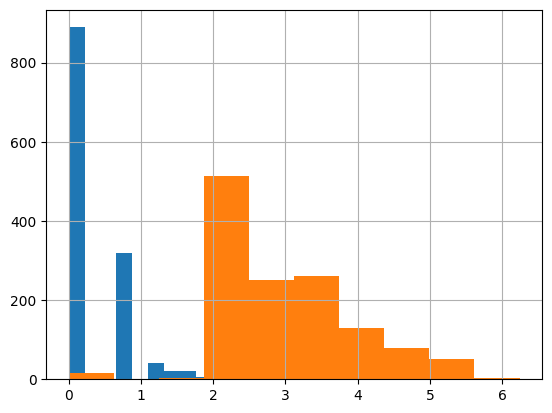

In [72]:
#create all categorical variables that we did above for both training and test sets
all_data['cabin_multiple'] = all_data.Cabin.apply(lambda x: 0 if pd.isna(x) else len(x.split(' ')))
all_data['cabin_adv'] = all_data.Cabin.apply(lambda x: str(x)[0])
all_data['numeric_ticket'] = all_data.Ticket.apply(lambda x: 1 if x.isnumeric() else 0)
all_data['ticket_letters'] = all_data.Ticket.apply(lambda x: ''.join(x.split(' ')[:-1]).replace('.','').replace('/','').lower() if len(x.split(' ')[:-1]) >0 else 0)
all_data['name_title'] = all_data.Name.apply(lambda x: x.split(',')[1].split('.')[0].strip())

#impute nulls for continuous data
#all_data.Age = all_data.Age.fillna(training.Age.mean())
all_data.Age = all_data.Age.fillna(training.Age.median())
#all_data.Fare = all_data.Fare.fillna(training.Fare.mean())
all_data.Fare = all_data.Fare.fillna(training.Fare.median())

#drop null 'embarked' rows. Only 2 instances of this in training and 0 in test
all_data.dropna(subset=['Embarked'],inplace = True)

#tried log norm of sibsp (not used)
all_data['norm_sibsp'] = np.log(all_data.SibSp+1)
all_data['norm_sibsp'].hist()

# log norm of fare (used)
all_data['norm_fare'] = np.log(all_data.Fare+1)
all_data['norm_fare'].hist()

# converted fare to category for pd.get_dummies()
all_data.Pclass = all_data.Pclass.astype(str)

#created dummy variables from categories (also can use OneHotEncoder)
all_dummies = pd.get_dummies(all_data[['Pclass','Sex','Age','SibSp','Parch','norm_fare','Embarked','cabin_adv','cabin_multiple','numeric_ticket','name_title','train_test']])

#Split to train test again
X_train = all_dummies[all_dummies.train_test == 1].drop(['train_test'], axis =1)
X_test = all_dummies[all_dummies.train_test == 0].drop(['train_test'], axis =1)


y_train = all_data[all_data.train_test==1].Survived
y_train.shape
# Scale data
from sklearn.preprocessing import StandardScaler
scale = StandardScaler()
all_dummies_scaled = all_dummies.copy()
all_dummies_scaled[['Age','SibSp','Parch','norm_fare']]= scale.fit_transform(all_dummies_scaled[['Age','SibSp','Parch','norm_fare']])
all_dummies_scaled

X_train_scaled = all_dummies_scaled[all_dummies_scaled.train_test == 1].drop(['train_test'], axis =1)
X_test_scaled = all_dummies_scaled[all_dummies_scaled.train_test == 0].drop(['train_test'], axis =1)

y_train = all_data[all_data.train_test==1].Survived


In [75]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

In [76]:
lr = LogisticRegression(max_iter = 2000)
cv = cross_val_score(lr,X_train_scaled,y_train,cv=5)
print(cv)
print(cv.mean())

[0.8258427  0.80898876 0.80337079 0.82022472 0.85310734]
0.8223068621849807


In [78]:
knn = KNeighborsClassifier()
cv = cross_val_score(knn,X_train,y_train,cv=5)
print(cv)
print(cv.mean())

[0.76966292 0.79775281 0.80898876 0.82022472 0.85310734]
0.8099473116231829


##Q4

In [ ]:
import numpy as np
import pandas as pd
from math import sqrt
from scipy.stats import skew
import matplotlib.pyplot as plt
from sklearn import linear_model
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split,cross_val_score,KFold
from sklearn.metrics import accuracy_score,mean_squared_error,make_scorer
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import RobustScaler

In [ ]:
plt.style.use(style='fivethirtyeight')
plt.rcParams['figure.figsize'] = (10, 6)

In [ ]:
#Load dataset
train = pd.read_csv('/content/sample_data/train.csv')
test = pd.read_csv('/content/sample_data/test.csv')

In [ ]:
train.head()

In [ ]:
print('Number of records in train dataset: ', len(train.index))
print('Number of columns in train dataset: ', len(train.columns))
print('Number of records in test dataset: ', len(test.index))
print('Number of columns in test dataset: ', len(test.columns))

In [ ]:
print ('Total data missing in train dataset', sum(train.isna().sum()))
print ('Total data missing in test dataset', sum(test.isna().sum()))

In [ ]:
train['SalePrice'].describe()

In [ ]:
numeric_cols = train.select_dtypes(include = [np.number])
corr = numeric_cols.corr()
print ('Attributes most correlated with SalePrice:'), print (corr['SalePrice'].sort_values(ascending = False)[:10], '\n')
print ('Attributes least correlated with SalePrice:'), print (corr['SalePrice'].sort_values(ascending = False)[-5:])

In [ ]:
plt.scatter(x = train['GrLivArea'], y = train['SalePrice'])
plt.ylabel('SalePrice')
plt.xlabel('GrLivArea')

In [ ]:
plt.scatter(x = train['GarageArea'], y = train['SalePrice'])
plt.ylabel('SalePrice')
plt.xlabel('GarageArea')

In [ ]:
train = train[train['GrLivArea'] < 4500]

In [ ]:
train = train[train['GarageArea'] < 1200]

In [ ]:
train_percentage = train.isnull().sum() / train.shape[0]
print (train_percentage[train_percentage > 0.80])
train = train.drop(train_percentage[train_percentage > 0.80].index, axis = 1)

In [ ]:
test_percentage = test.isnull().sum() / test.shape[0]
print (test_percentage[test_percentage > 0.80])
test = test.drop(test_percentage[test_percentage > 0.80].index, axis = 1)

In [ ]:
# Fill missing values by probability
for column in train.columns:
    null_vals = train.isnull().values
    a, b = np.unique(train.values[~null_vals], return_counts = 1)
    train.loc[train[column].isna(), column] = np.random.choice(a, train[column].isnull().sum(), p = b / b.sum())

In [ ]:
# Implementing Model
lr = linear_model.LinearRegression()
model = lr.fit(X_train, y_train)

In [ ]:
predictions = model.predict(X_test)
print(predictions)

In [ ]:
print ('MAE is:', mean_absolute_error(y_test, predictions))
print ('MSE is:', mean_squared_error(y_test, predictions))
print ('RMSE is:', sqrt(mean_squared_error(y_test, predictions)))

In [ ]:
knn_regressor = KNeighborsRegressor()

In [ ]:
models= [knn_regressor]

In [ ]:
def eval_model(model):
    eval_df=pd.DataFrame({'Model':[],'CV Accuracy Score':[]})
    # def rmse_scorer(y_true, y_pred):
    #     mse = mean_squared_error(np.log(y_true), np.log(y_pred))
    #     return np.sqrt(mse)
    cv_scores =np.sqrt (- cross_val_score(model, X, Y, cv=7, scoring='neg_mean_squared_error'))
    df=pd.DataFrame({'Model': [str(model)],'CV Accuracy Score':[cv_scores.mean()]})
    eval_df=pd.concat([eval_df,df],axis=1)
    return eval_df
def rmsle_cv(model):
    kf = KFold(5, shuffle=True, random_state=42).get_n_splits(train.values)
    rmse= np.sqrt(-cross_val_score(model, train.values, y_train, scoring="neg_mean_squared_error", cv = kf))
    return(rmse)
def eval_models(models):
    scores=[]
    for model in models:
        cv_scores =np.sqrt (- cross_val_score(model, X, Y, cv=7, scoring='neg_mean_squared_error'))
        scores.append(np.mean((cv_scores)))
    df=pd.DataFrame({'Model': models,'Score':scores})
    return df

In [ ]:
X=train.drop('SalePrice',axis=1)
Y=train.SalePrice

In [ ]:
scores=eval_models(models)
scores